In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from pathlib import Path
from lifelines import KaplanMeierFitter
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm

# Note: This script retains the original thesis development paths and is not intended
# to be executed in the public repository without access to the private data environment.

MAIN_DIR = Path("/Users/chanyoungwoo/Thesis/ATE_CATE")
CATE_H1_FP = MAIN_DIR / "Model_New_horizon_1/csf_cate_train.csv"
CATE_H2_FP = MAIN_DIR / "Model_New_horizon_2/csf_cate_train.csv"
CATE_H3_FP = MAIN_DIR / "Model_New_horizon_3/csf_cate_train.csv"
ATE_H1_TEST_FP = MAIN_DIR / "Model_New_horizon_1/csf_ate_test.csv"
ATE_H2_TEST_FP = MAIN_DIR / "Model_New_horizon_2/csf_ate_test.csv"
ATE_H3_TEST_FP = MAIN_DIR / "Model_New_horizon_3/csf_ate_test.csv"
CATE_H1_TEST_FP = MAIN_DIR / "Model_New_horizon_1/csf_cate_test.csv"
CATE_H2_TEST_FP = MAIN_DIR / "Model_New_horizon_2/csf_cate_test.csv"
CATE_H3_TEST_FP = MAIN_DIR / "Model_New_horizon_3/csf_cate_test.csv"
VI_H1_FP   = MAIN_DIR / "Model_New_horizon_1/csf_variable_importance.csv"
VI_H2_FP   = MAIN_DIR / "Model_New_horizon_2/csf_variable_importance.csv"
VI_H3_FP   = MAIN_DIR / "Model_New_horizon_3/csf_variable_importance.csv"
PARQUET_FP   = MAIN_DIR / "CSF_data_NEW2/cand_kipa_csf_data_train.parquet"
PARQUET_TEST_FP   = MAIN_DIR / "CSF_data_NEW2/cand_kipa_test_ver10.parquet"

h1 = pd.read_csv(CATE_H1_FP).rename(columns={"tau":"tau1"})
h2 = pd.read_csv(CATE_H2_FP).rename(columns={"tau":"tau2"})
h3 = pd.read_csv(CATE_H3_FP).rename(columns={"tau":"tau3"})
df = h1.merge(h2, on="PX_ID").merge(h3, on="PX_ID")

h1_test = pd.read_csv(CATE_H1_TEST_FP).rename(columns={"tau":"tau1"})
h2_test = pd.read_csv(CATE_H2_TEST_FP).rename(columns={"tau":"tau2"})
h3_test = pd.read_csv(CATE_H3_TEST_FP).rename(columns={"tau":"tau3"})
df_test = h1_test.merge(h2_test, on="PX_ID").merge(h3_test, on="PX_ID")

vi_h1 = pd.read_csv(VI_H1_FP)
vi_h2 = pd.read_csv(VI_H2_FP)
vi_h3 = pd.read_csv(VI_H3_FP)

In [ ]:
def _plot_density(ax, x, title):
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if x.size < 5:
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    lo, hi = np.percentile(x, [1, 99])
    xs = np.linspace(lo, hi, 400)

    kde = gaussian_kde(x)  
    ys = kde(xs)

    ax.plot(xs, ys, lw=2)
    ax.set_xlim(lo, hi)
    ax.set_yticks([])
    ax.set_xlabel(r"Predicted $\hat{\tau}$ (RMST days)")
    ax.set_title(title)

    med = np.median(x)
    q1, q3 = np.percentile(x, [25, 75])
    ax.axvline(med, linestyle="--", lw=1)
    ax.axvspan(q1, q3, alpha=0.15)

    ax.text(0.02, 0.95, f"n={len(x)}\nmedian={med:.1f}\nIQR=[{q1:.1f}, {q3:.1f}]",
            transform=ax.transAxes, ha="left", va="top", fontsize=10)

Saved:
- /Users/chanyoungwoo/Thesis/ATE_CATE/fig_cate_density_1x3.pdf
- /Users/chanyoungwoo/Thesis/ATE_CATE/fig_cate_density_1x3.png


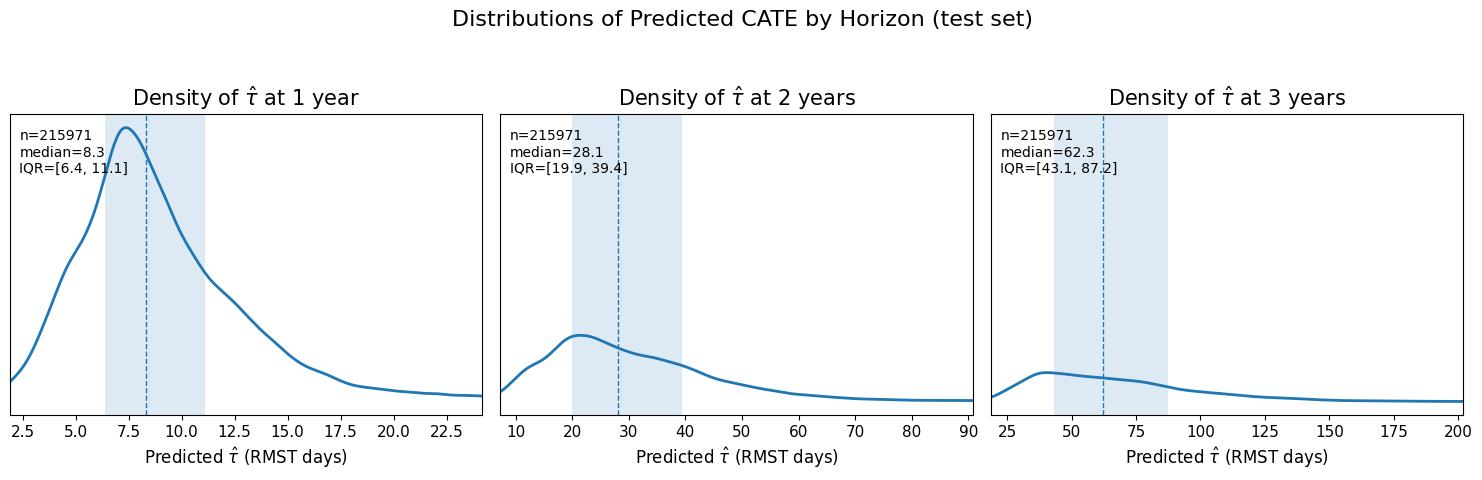

In [ ]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)

_plot_density(axes[0], df_test["tau1"].values, "Density of $\hat{\\tau}$ at 1 year")
_plot_density(axes[1], df_test["tau2"].values, "Density of $\hat{\\tau}$ at 2 years")
_plot_density(axes[2], df_test["tau3"].values, "Density of $\hat{\\tau}$ at 3 years")

fig.suptitle("Distributions of Predicted CATE by Horizon (test set)", y=1.04, fontsize=16)
plt.tight_layout()
´
out_pdf = MAIN_DIR / "fig_cate_density_1x3.pdf"
out_png = MAIN_DIR / "fig_cate_density_1x3.png"
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_png, dpi=600, bbox_inches="tight")
print(f"Saved:\n- {out_pdf}\n- {out_png}")

plt.show()